In [86]:
import numpy as np 
import faiss
import sys
import time
import csv
import os
from scipy.spatial.distance import cdist
from sklearn.preprocessing import StandardScaler
from numba import jit, prange
import threading
from concurrent.futures import ThreadPoolExecutor
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

module_path = '/home/cpanourg/projects/2-hdvc/'

if module_path not in sys.path:
    sys.path.append(module_path)

from src.utils import read_fvecs
from src.utils import append_or_create_csv
from src.utils import compute_distance_tables_threaded, compute_distance_tables_vectorized, adc_distances_batch_numba\
                    , compute_all_distances_batch, adc_distances_all_optimized, lsq_alpha_from_codes \
                    , lsq_dot_tables_vectorized, lsq_distances_batch_numba
  



In [87]:
# data_fp = '/mnthdd/cpanourg/2-hdvc/' # thalia
data_fp = '/data/cpanourg/2-hdvc/' # urania 
dataset_name = 'deep'


In [88]:

if dataset_name == 'gist':
    # Loading the GIST dataset
    db = np.array(read_fvecs(f'{data_fp}data/gist/gist_base.fvecs'))
    qr = np.array(read_fvecs(f'{data_fp}data/gist/gist_query.fvecs'))

elif dataset_name == 'deep':
    db = np.fromfile(f'{data_fp}data/deep1b/dataset/deep1b-96-100m.bin', dtype=np.float32).reshape(100_000_000, -1)
    qr = np.fromfile(f'{data_fp}data/deep1b/queries/queries-hard10p-deep1b-len96-1000.bin', np.float32).reshape(1000, -1)

elif dataset_name == 'cbf':
    dim_train = np.fromfile('/data/cpanourg/1-dtwrl/data/UCR_from_tslearn/CBF/dim_train.bin', dtype=int)[0]
    train = np.fromfile('/data/cpanourg/1-dtwrl/data/UCR_from_tslearn/CBF/X_train.bin',
                    dtype=np.float64).reshape(-1, dim_train)

    dim_test = np.fromfile('/data/cpanourg/1-dtwrl/data/UCR_from_tslearn/CBF/dim_test.bin', dtype=int)[0]
    test = np.fromfile('/data/cpanourg/1-dtwrl/data/UCR_from_tslearn/CBF/X_test.bin',
                    dtype=np.float64).reshape(-1, dim_test)

    db = np.concatenate((train, test), axis=0)
    train_db = db
    test_db = db
    qr = db

if dataset_name in ['gist', 'deep']:
    # Splitting into train and test sets
    train_size = 100_000
    test_size = 1_000_000

    idxs = np.random.choice(db.shape[0], train_size + test_size, replace=False)
    train_idxs, test_idxs = idxs[:train_size], idxs[train_size:]

    train_db, test_db = db[train_idxs], db[test_idxs]

elif dataset_name in 'cbf':
    train_size = train_db.shape[0]
    test_size = test_db.shape[0]

nb = test_db.shape[0]  # Number of database vectors
nq = qr.shape[0]  # Number of query vectors
dim = test_db.shape[1]  # Dimensionality of the vectors

print(f"Database shape: {test_db.shape}")
print(f"Query shape: {qr.shape}")
print(f"Dimension: {dim}")

# Ensure data is float32 for FAISS
train_db = train_db.astype(np.float32)
test_db = test_db.astype(np.float32)
qr = qr.astype(np.float32)

Database shape: (1000000, 96)
Query shape: (1000, 96)
Dimension: 96


In [105]:
# hps
# sampling_method = 'random'
# train_size_ratio = 0.1
k = 100  # Number of nearest neighbors


nbits = 8  # 2^nbits centroids per subquantizer
n_subquantizers = 32 # bits_per_vector // nbits  # Number of subquantizers
ksub = 1 << nbits  # 256 centroids per subquantizer

print("number of bits per vector:", n_subquantizers * nbits)

number of bits per vector: 256


In [106]:
dim % n_subquantizers

0

In [107]:

# # Sample training data if specified
# if sampling_method == 'random':
#     train_size = int(nb * train_size_ratio)
#     train_indices = np.random.choice(nb, train_size, replace=False)
#     train_data = db[train_indices]
#     print(f"Training on {train_size} vectors ({train_size_ratio:.1%} of database)")
# else:
#     train_data = db
#     print("Training on full database")

# Setup Product Quantizer
print(f"\nSetting up Product Quantizer...")
print(f"Parameters: {n_subquantizers} subquantizers, {nbits} bits each")
print(f"Compression: {dim*4} bytes -> {n_subquantizers} bytes per vector")

pq = faiss.ProductQuantizer(dim, n_subquantizers, nbits)

# Train the PQ
print("Training Product Quantizer...")
start_time = time.time()
pq.train(train_db)
train_time = time.time() - start_time
print(f"Training completed in {train_time:.2f} seconds")



Setting up Product Quantizer...
Parameters: 32 subquantizers, 8 bits each
Compression: 384 bytes -> 32 bytes per vector
Training Product Quantizer...
Training completed in 3.04 seconds


In [75]:

# Encode database vectors
print("Encoding database vectors...")
start_time = time.time()
try:
    codes = pq.compute_codes(test_db)
except TypeError:
    codes = np.zeros((nb, pq.code_size), dtype='uint8')
    pq.compute_codes(test_db, codes)
encoding_time = time.time() - start_time
print(f"Encoding completed in {encoding_time:.2f} seconds")
print(f"Codes shape: {codes.shape}")



Encoding database vectors...
Encoding completed in 1.93 seconds
Codes shape: (1000000, 32)


In [76]:

# Compute distance tables with optimization
print("Computing distance tables (optimized)...")
start_time = time.time()

# Get centroids from trained PQ
centroids = faiss.vector_to_array(pq.centroids).reshape(n_subquantizers, ksub, dim // n_subquantizers)

# Choose computation method based on dataset size
if nq > 1000:
    print("Using multi-threaded computation...")
    dis_tables = compute_distance_tables_threaded(qr, centroids, n_subquantizers, ksub, dim)
else:
    print("Using vectorized computation...")
    dis_tables = compute_distance_tables_vectorized(qr, centroids, n_subquantizers, ksub, dim)

distance_table_time = time.time() - start_time
print(f"Distance tables computed in {distance_table_time:.2f} seconds")


Computing distance tables (optimized)...
Using vectorized computation...
Distance tables computed in 0.25 seconds


In [77]:

sample_queries=1000
sample_db=10000

q_idx = np.random.choice(nq, min(sample_queries, nq), replace=False)
db_idx = np.random.choice(nb, min(sample_db, nb), replace=False)



qr_sample = qr[q_idx]
db_sample = test_db[db_idx]


# ADC distances for sampled subset
t0 = time.time()
adc_sample = adc_distances_batch_numba(
    dis_tables[q_idx], codes[db_idx], n_subquantizers
)
adc_time = time.time() - t0

print('adc time:', adc_time)

adc time: 0.02673196792602539


In [78]:
adc_sample

array([[104.78584, 100.72659,  92.68117, ..., 104.2466 , 107.12099,
        102.02532],
       [117.41236, 105.44659,  95.64296, ..., 100.21743,  99.13072,
         96.75033],
       [114.2013 ,  97.89932,  95.29286, ..., 107.87057, 106.58375,
        112.48199],
       ...,
       [114.02071,  97.77065, 102.26778, ...,  97.14029, 107.37892,
        104.09475],
       [119.76627,  94.02367, 106.09109, ..., 101.37857, 110.4485 ,
         96.82815],
       [113.38332, 107.46413,  97.71198, ..., 110.6012 , 102.85953,
        104.78016]], dtype=float32)

In [79]:

# Exact distances with cdist
t0 = time.time()
exact_sample = cdist(qr_sample, db_sample, metric="sqeuclidean").astype(np.float32)
cdist_time = time.time() - t0


In [80]:
exact_sample 

array([[100.52682, 109.63024, 103.67215, ..., 109.9828 , 107.6377 ,
        104.80592],
       [113.31827, 115.36498, 108.70837, ..., 104.35181, 100.14413,
         99.7123 ],
       [110.20711, 109.46026, 105.38954, ..., 113.83939, 106.83682,
        113.98037],
       ...,
       [110.70482, 108.27991, 112.84312, ..., 100.986  , 106.53638,
        107.07482],
       [116.68668, 105.71819, 115.17551, ..., 106.40672, 110.99391,
         99.27439],
       [109.4011 , 116.66277, 105.70132, ..., 113.22228, 105.33305,
        110.35712]], dtype=float32)

In [81]:
exact_sample.tofile(f'{data_fp}results/relerr/pq/exact_dists.bin')

In [82]:
exact_sample.shape, adc_sample.shape

((1000, 10000), (1000, 10000))

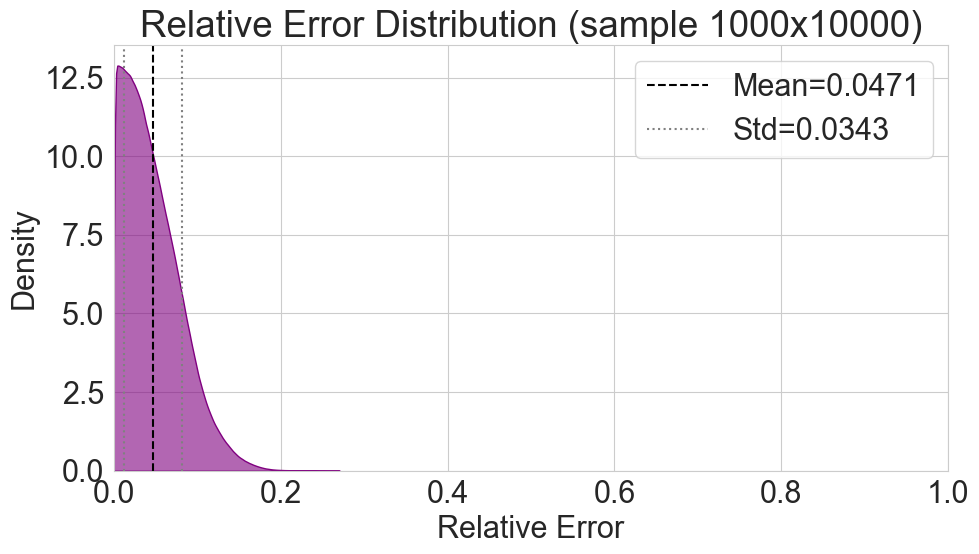

[cdist] sample 1000 queries x 10000 DB: 0.431s
Mean relative error=0.047055, Std=0.034341


In [83]:

plt.rcParams['font.family'] = 'serif'
sns.set_style("whitegrid")
# Relative errors
rel_error = np.abs(adc_sample - exact_sample) / (exact_sample + 1e-12)
rel_error.astype(np.float32).tofile(f'{data_fp}results/relerr/pq/{dataset_name}/rel_error_subq{n_subquantizers}_nbits{nbits}_db{sample_db//1000}k_qr{sample_queries//1000}k.bin')
mean_rel, std_rel = rel_error.mean(), rel_error.std()

# Plot KDE of relative errors
rel_error_flat = rel_error.ravel()
plt.figure(figsize=(10, 6))
plt.xlim(0, 1)
sns.kdeplot(rel_error_flat, fill=True, color="purple", alpha=0.6)
plt.axvline(mean_rel, linestyle="--", color="black", label=f"Mean={mean_rel:.4f}")
plt.axvline(mean_rel-std_rel, linestyle=":", color="grey")
plt.axvline(mean_rel+std_rel, linestyle=":", color="grey", label=f"Std={std_rel:.4f}")
plt.title(f"Relative Error Distribution (sample {len(q_idx)}x{len(db_idx)})")
plt.xlabel("Relative Error")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()

print(f"[cdist] sample {len(q_idx)} queries x {len(db_idx)} DB: {cdist_time:.3f}s")
print(f"Mean relative error={mean_rel:.6f}, Std={std_rel:.6f}")


In [84]:

summary = {
    "method": "PQ",
    "dataset": dataset_name,
    "nq": nq,
    "nb": nb,
    "nb_sample": len(db_idx),
    "dim": dim,
    "n_subquantizers": n_subquantizers,
    "nbits": nbits,
    "bits_per_vector": n_subquantizers * nbits,
    # "k": k,
    # "train_ratio": train_size_ratio,
    "train_size": train_size,
    "train_time_s": float(train_time),
    "encoding_time_s": float(encoding_time),
    "distance_table_time_s": float(distance_table_time),
    "cdist_time_s": float(cdist_time),
    "adc_time_s": float(adc_time),
    "rel_error_mean": float(mean_rel),
    "rel_error_std": float(std_rel),

}

csv_path=f"{data_fp}results/relerr/{dataset_name}_adc_vs_exact_eval.csv"

need_header = not Path(csv_path).exists() or Path(csv_path).stat().st_size == 0
with open(csv_path, "a", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=list(summary.keys()))
    if need_header:
        writer.writeheader()
    writer.writerow(summary)



In [85]:
import pandas as pd

pd.read_csv(f"{data_fp}results/relerr/{dataset_name}_adc_vs_exact_eval.csv").round(4)


,method,dataset,nq,nb,nb_sample,dim,n_subquantizers,nbits,bits_per_vector,train_size,train_time_s,encoding_time_s,distance_table_time_s,cdist_time_s,adc_time_s,rel_error_mean,rel_error_std
0,PQ,deep,1000,1000000,10000,96,12,8,96,100000,0.8817,0.2155,0.1199,0.5012,1.6657,0.2248,0.0781
1,OPQ,deep,1000,1000000,10000,96,12,8,96,100000,11.6713,0.2521,0.1687,0.5126,0.8565,0.1704,0.0968
2,LSQ,deep,1000,1000000,10000,96,12,8,96,100000,87.1700,56.1700,0.0000,0.5071,0.8000,0.1156,0.0749
3,RaBitQ,deep,1000,1000000,10000,96,1,96,96,100000,0.0245,0.5253,0.0000,0.5202,2.4192,0.0835,0.0645
4,PQ,deep,1000,1000000,10000,96,8,8,64,100000,0.6159,0.3039,0.0975,0.4582,0.0198,0.3109,0.0810
5,PQ,deep,1000,1000000,10000,96,4,8,32,100000,0.3108,1.1309,0.0886,0.4594,0.0123,0.4082,0.0905
6,PQ,deep,1000,1000000,10000,96,16,8,128,100000,2.0601,1.5532,0.1379,0.5434,0.0270,0.1603,0.0723
7,PQ,deep,1000,1000000,10000,96,32,8,256,100000,3.9820,1.9301,0.2465,0.4308,0.0267,0.0471,0.0343
